# Chapter 44 — The Instruments: Load Cells, Pressure Transducers, Torque Meters, and Multi-Axis Load Cells
### *Modern Strain Gage Technology* — Companion Notebook

**A calibration certificate is a promise about accuracy — and this notebook shows how that promise is measured: a straight line drawn through the data, then judged by the small errors that refuse to lie on it.**

Companion notebook to Chapter 44 — The Instruments: Load Cells, Pressure Transducers, Torque Meters, and Multi-Axis Load Cells.

A calibrated transducer is characterized by three performance specifications beyond sensitivity: *linearity*, *hysteresis*, and *repeatability*. These numbers — typically expressed as a percentage of full-scale output — set the systematic error budget of the measurement. Together they define the *combined error*, and the larger of hysteresis and linearity usually dominates.

*Linearity error* is the maximum deviation of the actual output from the best-fit straight line through the calibration data, expressed as a fraction of full scale. *Hysteresis* is the maximum difference in output for the same applied load when it is approached from above versus from below — a consequence of friction, internal damping, and in some cases plasticity in the spring element. This notebook generates a representative multi-point calibration dataset, fits the calibration line, and computes both errors directly from the data. The data are synthetic but shaped like a real cell's: the nonlinearity is a smooth bow, and the hysteresis is zero at full load (where the loading and unloading branches meet) and largest near mid-range. The magnitudes (about 0.1% FS of nonlinearity and 0.12% FS of hysteresis) are deliberately large enough to be visible; a precision load cell would show errors several times smaller.

**This notebook demonstrates:**
1. **Load cell calibration** — a multi-point loading and unloading run, a least-squares line fitted to the loading branch, the nonlinearity about that line, and the hysteresis between the branches, all in one figure (Figure 44.3)

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Consistent, publication-style plot defaults
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All notebook figures are written here; the path matches the \includegraphics
# calls in Chapter 44. Do not rename these output files.
OUT_DIR = Path("../src/media/ch44")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Calibration, Nonlinearity, and Hysteresis (Figure 44.3)

A multi-point calibration applies known loads in ascending steps (*loading*) and then descending steps (*unloading*), recording the bridge output at each step. A least-squares straight line fitted to the loading data defines the sensitivity. The deviation of the loading points from that line, as a percentage of full-scale output, is the *nonlinearity*; the difference between the unloading and loading outputs at the same load is the *hysteresis*.

At full scale both errors are far too small to see on the calibration curve itself, so the figure magnifies them in two further panels. The hysteresis is zero at the top load, where the two branches meet, and peaks near mid-range; the small value left at zero load is the return-to-zero error after the load comes off.

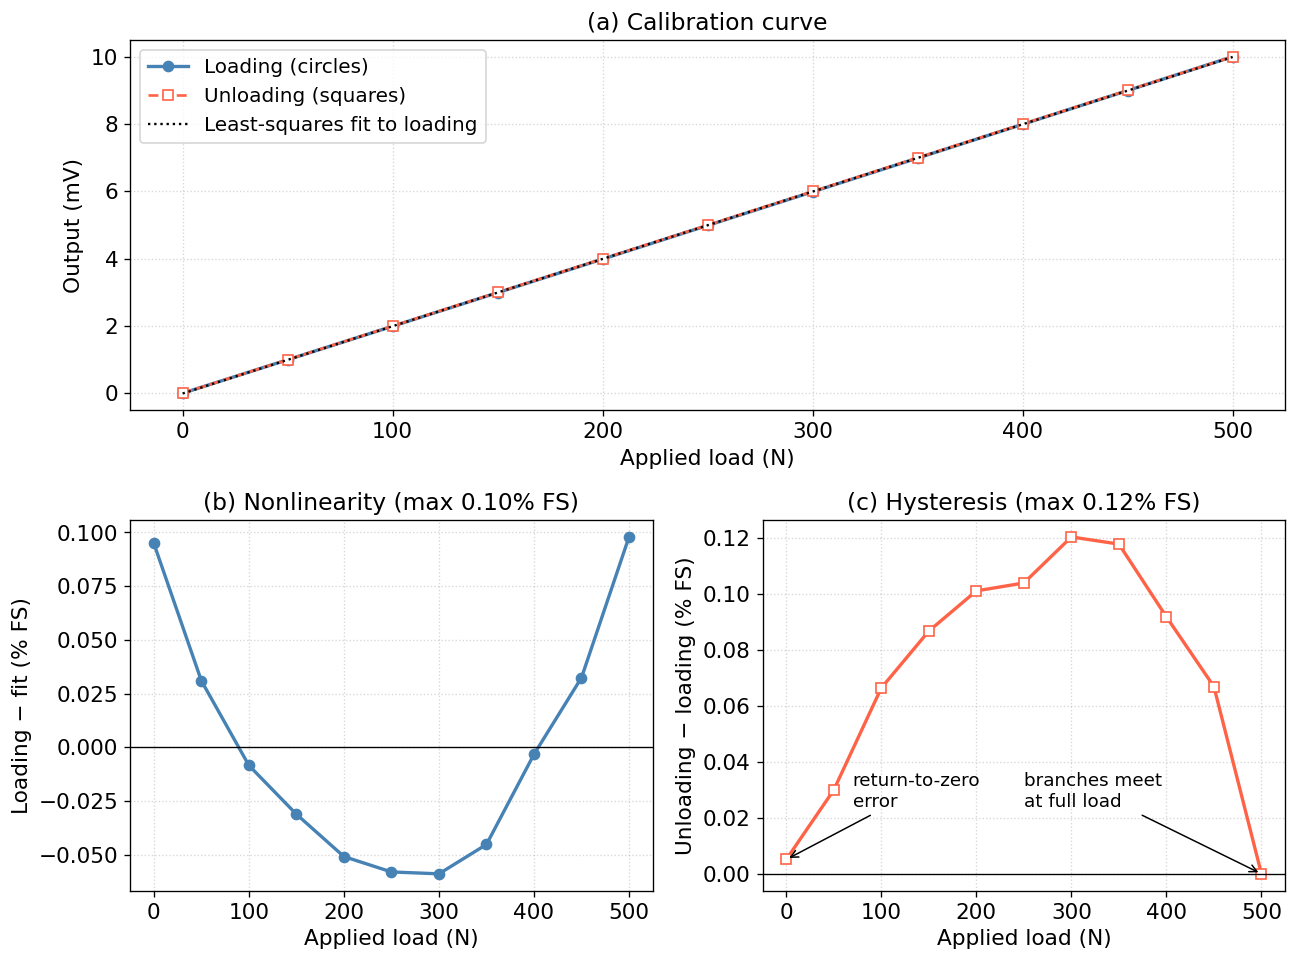

Sensitivity: 0.02000 mV/N, intercept -8.33 uV
Max nonlinearity: 0.098% FS
Max hysteresis:   0.120% FS


In [2]:
# Synthetic but physically shaped calibration of a 500 N, 10 mV full-scale load cell.
RNG_SEED     = 44
F_MAX_N      = 500.0          # rated load, N
SENS_MV_PER_N = 0.020         # nominal sensitivity, mV/N -> 10 mV full scale
NL_PEAK_FS   = 0.0015         # terminal nonlinearity (bow) at mid-range, fraction of FS
HYST_PEAK_FS = 0.0010         # hysteresis at mid-range, fraction of FS
NOISE_FS     = 0.00008        # 1-sigma reading noise, fraction of FS

rng = np.random.default_rng(RNG_SEED)
F = np.linspace(0, F_MAX_N, 11)                     # 0, 50, ..., 500 N
x = F / F_MAX_N
FS_MV = SENS_MV_PER_N * F_MAX_N

V_load   = SENS_MV_PER_N * F - NL_PEAK_FS * FS_MV * 4 * x * (1 - x)
V_unload = V_load + HYST_PEAK_FS * FS_MV * 4 * x * (1 - x) ** 0.8
V_unload[0] += 0.00015 * FS_MV                       # small return-to-zero error
V_load   += rng.normal(0, NOISE_FS * FS_MV, F.size)
V_unload += rng.normal(0, NOISE_FS * FS_MV, F.size)
V_unload[-1] = V_load[-1]                            # same reading at the turnaround point


def fit_calibration(force, output):
    # Least-squares straight line through the loading branch: (slope, intercept, fitted).
    slope, intercept = np.polyfit(force, output, 1)
    return slope, intercept, slope * force + intercept


sensitivity, intercept, V_fit = fit_calibration(F, V_load)
fs_fit = sensitivity * F_MAX_N                       # fitted full-scale output, mV
nonlin_pct = (V_load - V_fit) / fs_fit * 100
hyst_pct = (V_unload - V_load) / fs_fit * 100

plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14})
fig = plt.figure(figsize=(11, 8.2))
gs = fig.add_gridspec(2, 2, height_ratios=[1.0, 1.0])
axes = [fig.add_subplot(gs[0, :]), fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]
ax = axes[0]
ax.plot(F, V_load, 'o-', color='steelblue', lw=2, label='Loading (circles)')
ax.plot(F, V_unload, 's--', color='tomato', lw=1.6, mfc='white', label='Unloading (squares)')
ax.plot(F, V_fit, 'k:', lw=1.4, label='Least-squares fit to loading')
ax.set_xlabel('Applied load (N)'); ax.set_ylabel('Output (mV)')
ax.set_title('(a) Calibration curve'); ax.legend(fontsize=12, loc='upper left')
ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[1]
ax.plot(F, nonlin_pct, 'o-', color='steelblue', lw=2)
ax.axhline(0, color='black', lw=0.8)
ax.set_xlabel('Applied load (N)'); ax.set_ylabel('Loading − fit (% FS)')
ax.set_title(f'(b) Nonlinearity (max {np.max(np.abs(nonlin_pct)):.2f}% FS)')
ax.grid(True, linestyle=':', alpha=0.5)

ax = axes[2]
ax.plot(F, hyst_pct, 's-', color='tomato', lw=2, mfc='white')
ax.axhline(0, color='black', lw=0.8)
ax.annotate('return-to-zero\nerror', xy=(F[0], hyst_pct[0]), xytext=(70, hyst_pct.max() * 0.2),
            fontsize=11, arrowprops=dict(arrowstyle='->', lw=0.9))
ax.annotate('branches meet\nat full load', xy=(F[-1], hyst_pct[-1]), xytext=(250, hyst_pct.max() * 0.2),
            fontsize=11, arrowprops=dict(arrowstyle='->', lw=0.9))
ax.set_xlabel('Applied load (N)'); ax.set_ylabel('Unloading − loading (% FS)')
ax.set_title(f'(c) Hysteresis (max {np.max(np.abs(hyst_pct)):.2f}% FS)')
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig44_nb1_calibration_hysteresis.png', bbox_inches='tight', dpi=300)
plt.show()

print(f"Sensitivity: {sensitivity:.5f} mV/N, intercept {intercept*1000:.2f} uV")
print(f"Max nonlinearity: {np.max(np.abs(nonlin_pct)):.3f}% FS")
print(f"Max hysteresis:   {np.max(np.abs(hyst_pct)):.3f}% FS")

---
## Where to take this next

The dataset above is a single, clean calibration cycle. A few concrete extensions turn it into a more realistic characterization tool:

1. **Add repeatability from repeated cycles.** Generate several loading/unloading cycles with a small amount of seeded random noise (`rng = np.random.default_rng(0)`), then compute repeatability as the spread of outputs at each force level. Combine linearity, hysteresis, and repeatability in quadrature to report a single *combined error* — the number that actually caps the certificate accuracy.
2. **Test the reference-line convention.** Compare a two-parameter fit (slope + intercept) against a forced-through-zero fit, and watch how the choice of reference line changes the reported linearity error. Calibration standards specify which convention applies, and the difference is not cosmetic.
3. **Correct the nonlinearity.** The bow in panel (b) is a quadratic term, like the large-deflection behavior discussed for pressure transducers in Chapter 44. Fit a second-order polynomial instead of a line and see how much of the nonlinearity it removes, and how little of the hysteresis.